## Imports

Standard data-science stack. `numpy` and `scipy.sparse` are used later to build the final sparse column vectors written to disk. `matplotlib` and `seaborn` are only needed for the exploratory visualisation cell — they have no effect on the saved outputs.

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load source parquets

Loads the five raw parquet tables exported from MusicBrainz:

- `mb_artist_ratings` / `mb_album_ratings` — user-submitted ratings (columns: `rating`, `rating_count`)
- `mb_artist_credit` — the join table that links an album's `artist_credit` composite ID back to individual `artist_id` values; needed later to map artist reputation onto albums
- `mb_album` / `mb_artist` — master entity tables used for ID lookups

`artist_credit` is by far the largest table (~2.3 M rows) because MusicBrainz models multi-artist credits as a list of individual artist positions. It is loaded in full here and filtered down in a later cell.

In [36]:
# Load the ratings dataframe from the parquet tables we created
artist_ratings = pd.read_parquet('../data/mb_artist_ratings.parquet')
album_ratings = pd.read_parquet('../data/mb_album_ratings.parquet')
artist_credit = pd.read_parquet('../data/mb_artist_credit.parquet')
albums = pd.read_parquet('../data/mb_album.parquet')
artists = pd.read_parquet('../data/mb_artist.parquet')

# Verify the loads
dataframes = {
    "Artist Ratings": artist_ratings,
    "Album Ratings": album_ratings,
    "Artist Credit": artist_credit,
}

for name, df in dataframes.items():
    print(f"✅ {name}: {df.shape[0]:,} rows loaded.")

✅ Artist Ratings: 77,571 rows loaded.
✅ Album Ratings: 143,733 rows loaded.
✅ Artist Credit: 2,337,824 rows loaded.


## Define `apply_zero_anchored_bayesian`

Defines the core scoring function. Understanding the formula and the choice of C is essential for anyone modifying the feature pipeline.

**The formula:** `weighted_score = (R × v) / (v + C)`

- `R` = mean rating (0–100 in MusicBrainz)
- `v` = number of ratings (`rating_count`)
- `C` = confidence constant (set to 5 here)

**Why not just use the raw mean?** An album with one 5-star rating and an album with 10,000 5-star ratings would both score 100. That inflates confidence in sparse data and produces noisy feature vectors.

**Why zero-anchored rather than mean-anchored?** The classic IMDB Bayesian formula pulls low-count items toward the *global mean*, which is appropriate when you want a ranked leaderboard. Here the goal is a *sparse ML feature column*: ~95% of items have no ratings at all. Pulling unrated items toward the global mean would inject a non-zero signal where there is genuinely no information. Anchoring to 0 instead means "no data → no signal", which is the right default for a feature that will be concatenated with other zero-padded sparse vectors.

**Why C=5?** It represents the point at which a rating carries half its full weight — an item needs roughly 5 ratings before its score rises to 50% of `R`. With music data this sparse, a higher C (e.g. 25) would suppress too many legitimately well-rated niche artists; a lower C (e.g. 1) would let a single rating dominate. C=5 is a pragmatic midpoint that was validated visually in the distribution plots below.

The function accepts a dict of DataFrames so it can process artists and albums in one pass. `Artist Credit` is passed in the same dict but is silently skipped because it lacks `rating` / `rating_count` columns — the guard clause handles that gracefully.

In [37]:
def apply_zero_anchored_bayesian(df_dict, confidence_constant=5):
    """
    Applies a zero-anchored Bayesian weighting to a dictionary of dataframes.
    Designed specifically for sparse ML features (<5% rated), forcing unrated
    and low-count items toward a baseline of 0.
    
    Parameters:
    -----------
    df_dict : dict
        Dictionary of pandas DataFrames containing 'rating' and 'rating_count'.
    confidence_constant : int or float, default 5
        The 'C' factor. How aggressively to penalize low rating counts.
        
    Returns:
    --------
    dict
        A new dictionary with DataFrames containing the engineered 'weighted_score'.
    """
    processed_dict = {}
    C = confidence_constant
    
    for name, df in df_dict.items():
        df_clean = df.copy()
        
        # Check for required columns
        if 'rating' not in df_clean.columns or 'rating_count' not in df_clean.columns:
            print(f"⚠️ Skipping '{name}': Missing required columns.")
            continue
            
        # Extract and fill nulls safely for matrix math
        v = df_clean['rating_count'].fillna(0)
        R = df_clean['rating'].fillna(0)
        
        # Apply Option 2 Formula: (R * v) / (v + C)
        # When v=0, this naturally results in 0.0
        df_clean['weighted_score'] = (R * v) / (v + C)
        
        print(f"✅ Processed '{name}': Anchored to 0.0 | Max Score Possible ~100.0 | C = {C}")
        processed_dict[name] = df_clean
        
    return processed_dict

## Apply Bayesian weighting

Calls the function defined above with `C=5` across the ratings DataFrames. The result is two DataFrames — `artist_features` and `album_features` — each with a new `weighted_score` column on a 0–100 scale.

The `Artist Credit` skipped warning is expected: it was included in the dict only so the same data structure could be reused from the load cell, not because it has ratings.

In [38]:
# Process the dictionary
weighted_dfs = apply_zero_anchored_bayesian(dataframes, confidence_constant=5)

# Extract your ML-ready features
artist_features = weighted_dfs["Artist Ratings"]
album_features = weighted_dfs["Album Ratings"]

✅ Processed 'Artist Ratings': Anchored to 0.0 | Max Score Possible ~100.0 | C = 5
✅ Processed 'Album Ratings': Anchored to 0.0 | Max Score Possible ~100.0 | C = 5
⚠️ Skipping 'Artist Credit': Missing required columns.


## Normalise scores to [0, 1]

Divides every `weighted_score` by 100 to produce `weighted_score_norm`. This is a straightforward linear rescale, not a min-max or z-score normalisation.

**Why divide by 100 specifically?** MusicBrainz stores ratings as integers 0–100, so 100 is the hard maximum the Bayesian formula can ever produce (when `v → ∞` and `R = 100`). Dividing by 100 gives a value with a known, fixed ceiling of 1.0.

**Why does scale matter?** In notebook 03, rating vectors are concatenated column-wise with other binary or [0,1]-normalised feature blocks (e.g. tag presence, country match). If ratings were left on a 0–100 scale they would dominate the KNN distance calculation by a factor of 100 relative to binary features. Normalising here ensures ratings contribute proportionally when Euclidean or cosine distance is computed.

In [39]:
# Scale the rating feature down so it shares the exact same weight as a binary country match
artist_features['weighted_score_norm'] = artist_features['weighted_score'] / 100.0
album_features['weighted_score_norm'] = album_features['weighted_score'] / 100.0

## Visualise score distributions

Produces a 2×2 grid to sanity-check the Bayesian weighting before any data is written to disk.

**Top row — log scale, all items:** Shows the full dataset including unrated items (score = 0). The y-axis is log-scaled because ~95% of items score exactly 0; without log scale the non-zero tail would be invisible. If the zero bar dominates massively that confirms the sparsity assumption underlying the zero-anchoring choice.

**Bottom row — rated items only, linear scale:** Filters to `weighted_score_norm > 0` and switches to a linear y-axis with a KDE overlay. This is the more useful view for checking whether the score distribution among *actually rated* items looks reasonable — you want a roughly bell-shaped or right-skewed distribution, not a spike at one extreme which would suggest a bug in the formula or a data import issue.

These plots are exploratory only and do not affect any saved outputs.

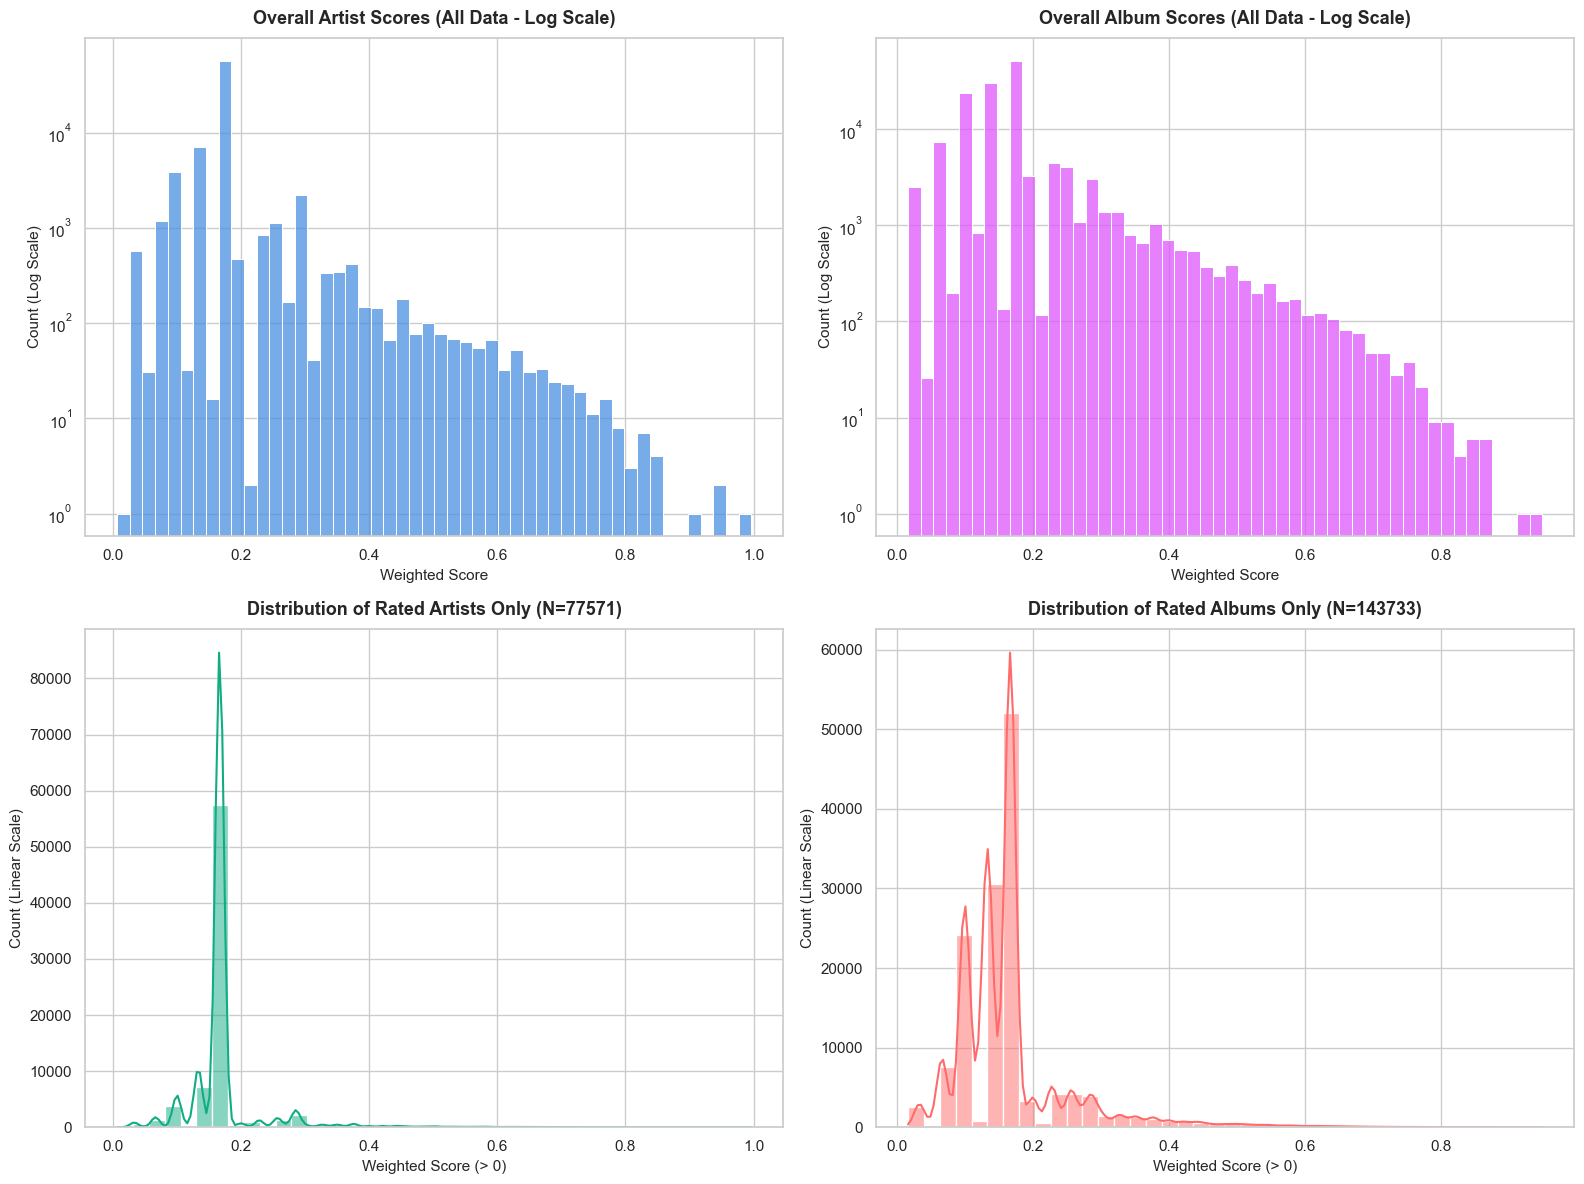

In [40]:
# Set up the plotting style for clean, readable visuals
sns.set_theme(style="whitegrid")

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Extract dataframes from your processed dictionary for convenience
artist_df = weighted_dfs["Artist Ratings"]
album_df = weighted_dfs["Album Ratings"]

# ----------------------------------------------------------------------
# ROW 1: OVERALL DISTRIBUTIONS (Log Scale to handle 95% Zeros)
# ----------------------------------------------------------------------

# Top Left: All Artists
sns.histplot(data=artist_df, x='weighted_score_norm', bins=50, ax=axes[0, 0], color='#4A90E2', kde=False)
axes[0, 0].set_yscale('log')  # Crucial for seeing the sparse tail
axes[0, 0].set_title('Overall Artist Scores (All Data - Log Scale)', fontsize=13, weight='bold', pad=10)
axes[0, 0].set_xlabel('Weighted Score', fontsize=11)
axes[0, 0].set_ylabel('Count (Log Scale)', fontsize=11)

# Top Right: All Albums
sns.histplot(data=album_df, x='weighted_score_norm', bins=50, ax=axes[0, 1], color='#E056FD', kde=False)
axes[0, 1].set_yscale('log')  # Crucial for seeing the sparse tail
axes[0, 1].set_title('Overall Album Scores (All Data - Log Scale)', fontsize=13, weight='bold', pad=10)
axes[0, 1].set_xlabel('Weighted Score', fontsize=11)
axes[0, 1].set_ylabel('Count (Log Scale)', fontsize=11)


# ----------------------------------------------------------------------
# ROW 2: ACTIVE SIGNALS ONLY (Filtering out the 0.0 unrated rows)
# ----------------------------------------------------------------------

# Filter for rows that actually received ratings
active_artists = artist_df[artist_df['weighted_score_norm'] > 0]
active_albums = album_df[album_df['weighted_score_norm'] > 0]

# Bottom Left: Rated Artists Only
sns.histplot(data=active_artists, x='weighted_score_norm', bins=40, ax=axes[1, 0], color='#10AC84', kde=True)
axes[1, 0].set_title(f'Distribution of Rated Artists Only (N={len(active_artists)})', fontsize=13, weight='bold', pad=10)
axes[1, 0].set_xlabel('Weighted Score (> 0)', fontsize=11)
axes[1, 0].set_ylabel('Count (Linear Scale)', fontsize=11)

# Bottom Right: Rated Albums Only
sns.histplot(data=active_albums, x='weighted_score_norm', bins=40, ax=axes[1, 1], color='#FF6B6B', kde=True)
axes[1, 1].set_title(f'Distribution of Rated Albums Only (N={len(active_albums)})', fontsize=13, weight='bold', pad=10)
axes[1, 1].set_xlabel('Weighted Score (> 0)', fontsize=11)
axes[1, 1].set_ylabel('Count (Linear Scale)', fontsize=11)


# Adjust layout to prevent any text/label overlapping or truncation
plt.tight_layout()

# Render the plots in your notebook
plt.show()

## Map primary artists to albums via `artist_credit`

**Why is this needed?** MusicBrainz has direct ratings for albums, but the coverage is thin — most albums have no rating at all. An artist's rating aggregates community opinion across their entire discography and tends to be more populated. Using the artist's score as a proxy feature for their albums adds a meaningful signal for albums that would otherwise contribute only zeros.

**How `artist_credit` works:** MusicBrainz does not store `artist_id` directly on the album row. Instead each album stores an `artist_credit` integer that identifies a *credit group* (which may list one or more artists at different `position` values). To get the primary (lead) artist we filter to `position == 0`.

**The `artist_id != 1` and `artist_credit != 1` guards:** ID 1 in MusicBrainz is a special "Various Artists" placeholder. Mapping the Various Artists rating onto compilations would be meaningless noise, so those rows are excluded.

**`drop_duplicates(subset=['artist_credit'])`:** Ensures each credit group maps to exactly one artist. Some credit groups list the same artist twice at position 0 due to data entry quirks; deduplication prevents a many-to-one fan-out that would produce duplicate album rows downstream.

The resulting `album_to_artist` DataFrame is a clean `album_id → artist_id` lookup table with ~1 M rows.

In [41]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix, save_npz
import pickle

print("1. Isolating primary artists from artist_credits...")
# Filter mapping table down right away to save memory
primary_credits = artist_credit[
    (artist_credit['position'] == 0) & 
    (artist_credit['artist_id'] != 1) & 
    (artist_credit['artist_credit'] != 1)
][['artist_credit', 'artist_id']].drop_duplicates(subset=['artist_credit'])

print("2. Mapping albums to their primary artist ID...")
# Merge with albums to get a definitive album_id -> artist_id lookup map
# We use [['id', 'artist_credit']] from albums to keep memory small
album_to_artist = albums[['id', 'artist_credit']].merge(
    primary_credits, 
    on='artist_credit', 
    how='inner'
).rename(columns={'id': 'album_id'})

print(f"Mapped {len(album_to_artist):,} albums to their primary artists.")

1. Isolating primary artists from artist_credits...
2. Mapping albums to their primary artist ID...
Mapped 1,004,510 albums to their primary artists.


## Align artist ratings to album index, build primary-artist ratings matrix

This cell does two distinct things: it joins artist scores onto albums, and then aligns the result to the exact row order defined in `01-album-artist-index.ipynb`.

**Step 3 — joining artist scores:** Merges `artist_features` (indexed by `artist_id`) onto `album_to_artist` using the artist ID as the key. After setting `album_id` as the index, we have a Series of `weighted_score_norm` values keyed by album ID — but only for albums whose primary artist has a rating.

**Step 4 — `reindex` + `fillna(0.0)` alignment:** This is the critical step for pipeline correctness. `unique_album_ids` is the ordered list of album IDs produced by `01-album-artist-index.ipynb` and shared across every feature block. Using `.reindex(unique_album_ids)` guarantees:

1. The output vector has exactly the same number of rows as every other feature matrix, in the same order.
2. Albums that appear in the master index but have no primary-artist rating are explicitly set to `0.0` rather than being silently dropped or left as `NaN` (which would cause errors in downstream matrix arithmetic).

Without this alignment step, different feature matrices could have different row counts or orderings, making the final horizontal stack in notebook 03 produce nonsense.

**Output shape `(1,008,102, 1)`:** Stored as a transposed CSR sparse matrix (1 column = 1 feature). The transpose is a scipy convention for stacking feature columns horizontally with `hstack` in notebook 03.

In [42]:
print("3. Joining artist ratings onto mapped albums...")
# Merge the normalized artist scores into our lookup map
album_artist_ratings = album_to_artist.merge(
    artist_features[['weighted_score_norm']], 
    left_on='artist_id', 
    right_index=True, 
    how='inner'
)

# Set album_id as index for seamless alignment
album_artist_ratings = album_artist_ratings.set_index('album_id')

print("4. Aligning artist rating features to master album matrix index...")
# Load the master unique album IDs array (from your pickle file)
with open('../data/features/album_ids.pkl', 'rb') as f:
    unique_album_ids = pickle.load(f)

# Reindex using the exact universe of album IDs. 
# Albums with missing primary artist ratings safely default to 0.0
aligned_artist_ratings = album_artist_ratings.reindex(unique_album_ids)['weighted_score_norm'].fillna(0.0).values

# Convert to 2D sparse column vector (1,008,102 rows x 1 column)
X_album_artist_ratings_sparse = csr_matrix(aligned_artist_ratings.astype('float32')).T
print(f"🚀 Final Album-Level Artist Ratings Shape: {X_album_artist_ratings_sparse.shape}")

3. Joining artist ratings onto mapped albums...
4. Aligning artist rating features to master album matrix index...
🚀 Final Album-Level Artist Ratings Shape: (1008102, 1)


In [44]:
import os
import pickle
from scipy.sparse import csr_matrix, save_npz

# 1. Ensure the target directory exists
os.makedirs('../data/features', exist_ok=True)

# 2. Load the index mappings exported by 01-album-artist-index.ipynb
print("Loading master row index configurations...")
with open('../data/features/artist_ids.pkl', 'rb') as f:
    unique_artist_ids = pickle.load(f)

with open('../data/features/album_ids.pkl', 'rb') as f:
    unique_album_ids = pickle.load(f)

# 3. Align and export Artist Ratings
print("Aligning and exporting Artist Ratings...")
aligned_artist_ratings = artist_features.reindex(unique_artist_ids)['weighted_score_norm'].fillna(0.0).values
X_artist_ratings_sparse = csr_matrix(aligned_artist_ratings.astype('float32')).T
save_npz('../data/features/artist_ratings_matrix.npz', X_artist_ratings_sparse)

# 4. Align and export Album Ratings
print("Aligning and exporting Album Ratings...")
aligned_album_ratings = album_features.reindex(unique_album_ids)['weighted_score_norm'].fillna(0.0).values
X_album_ratings_sparse = csr_matrix(aligned_album_ratings.astype('float32')).T
save_npz('../data/features/album_ratings_matrix.npz', X_album_ratings_sparse)

print("🎉 Ratings successfully exported as sparse vectors to data/features/")

Loading master row index configurations...
Aligning and exporting Artist Ratings...
Aligning and exporting Album Ratings...
🎉 Ratings successfully exported as sparse vectors to data/features/
